# Modeling the FIR Line Signal for TIM

The workbook contains some basic steps towards modeling the expected signal from
[CII] and other far infrared lines that TIM will observe. To do this we use halo
catalogs from the Illustris-TNG simulations, combined with a prescription for 
assigning an SFRs to based on each halos mass and a prescription for assigning 
FIR line luminosities based on the SFRs.

This workbook assesses a number of different prescriptions for assigning FIR 
luminosities, and compares the power spectra and luminosity functions that result
from these various prescriptions. A key goal is to update our expectations for 
the signals we might see, as the previous work on this subject (Uzgil et al. 2014)
unfortunately used scaling relations from Spignolio et al. 2012) that were 
significantly revised in an eratum published after the Uzgil paper was finished.

## Scaling Relations Considered
### SFR
For assigning SFRs to dark matter halos we use the prescription of Behroozi et 
al. 2013. These results have since been updated, but as our primary interest is
in modeling z<2 where observational constraints have not changed significantly,
recent updates to the model should not be particularly relevant.

### Line Luminosity
The TIM bandpass covers a wide array of FIR lines. We sumarrize a few of the 
important ones in the table below:

| Line  | rest wavelength (um) | redshift range for 240-420 um |
|-------|----------------------|-------------------------------|
[CII] | 157.7 | 0.52-1.66
[NII] | 122.9 | 0.95-2.42
[OIII] | 88.4 | 1.71-3.75
[OI] | 63.2 | 2.80-5.65
CO(7-6) | 371.7 | 0.00-0.13
CO(8-7) | 325.2 | 0.00-0.29
CO(10-9) | 289.1 | 0.00-0.45
CO(11-10) | 260.2 | 0.00-0.61
CO(12-11) | 236.6 | 0.01-0.78

*additional CO lines of higher J will continue to redshift into the band

To assign FIR line luminosities we will use scaling relations of the form
$$\log L_\mathrm{line} = a\log\mathrm{SFR}+b+\epsilon(\sigma)$$
where $a$ and $b$ are the slope and intercept of a fitted power law relating
line luminosity and SFR, while $\epsilon(\sigma)$ adds a random component drawn
from a lognormal distribution of width $\sigma$ to account for variations between
galaxies.

We will initially consider four sets of scaling relations for the FIR 
line luminosities:
- The relations from Spignolio et al. 2012, as updated in their 2014 erratum. 
These relations cover a full suite of FIR lines: the most relevant of which are
[CII], [NII], [OI], and [OIII] 88um.
- The relations from DeLooze et al. 2016, which use a broad sample of galaxies
ranging from local dwarfs to high redshift SMGs. This paper provides scaling
relations only for [CII], [OI], and [OIII] 88um.
- The relations from Schraer et al. 2020, which are based on the ALPINE sample
of z~4-6 galaxies along with a compilation of other high redshift results. This
provides an additonal scaling relation for [CII]
- The relations used in Uzgil et al. 2014 - these are incorrect, but provide a 
baseline for comparison with our updated results.

For the high J CO lines we will use the scaling relation from
Kamenetzky et al. 2016.

In [1]:
# Here we load the relevant properties (for those already packaged with SimIM)
# or define property objects for the scaling relations not already defined.
import numpy as np
import matplotlib.pyplot as plt
from simim.lineprops.lineprops import prop, multiprop

# Some things we'll use globally
rng_seed = 327903736

# For spinoglio/Uzgil models with no fitted constraint on the dispersion
default_scatter = 0.4 # based on DeLooze fit for whole CII sample

# For Behroozi et al. SFRs:
from simim.lineprops.lineprops import prop_behroozi_sfr

# For spinoglio et al:
from simim.lineprops.lineprops import prop_spinoglio_fir
kws_spinoglio_cii = {'line':'[CII]','sig_scatter':default_scatter,'rng':np.random.default_rng(rng_seed)}
kws_spinoglio_nii = {'line':'[NII]','sig_scatter':default_scatter,'rng':np.random.default_rng(rng_seed)}
kws_spinoglio_oiii = {'line':'[OIII]88um','sig_scatter':default_scatter,'rng':np.random.default_rng(rng_seed)}
kws_spinoglio_oi = {'line':'[OI]','sig_scatter':default_scatter,'rng':np.random.default_rng(rng_seed)}

# For DeLooze et al:
from simim.lineprops.lineprops import prop_delooze_fir
kws_delooze_cii = {'line':'[CII]','rng':np.random.default_rng(rng_seed)}
kws_delooze_oiii = {'line':'[OIII]','rng':np.random.default_rng(rng_seed)}
kws_delooze_oi = {'line':'[OI]','rng':np.random.default_rng(rng_seed)}

# For Schaerer et al:
def lcii_schaerer(sfr,scatter_dex=0.4,rng=np.random.default_rng()):

    # Determine mean luminosity from Schaerer fit:
    a = 1.17
    b = 6.61
    lcii = 10**(a*np.log10(np.array(sfr))+b)

    # Add a lognormal scatter
    lcii = lcii / 10**(scatter_dex**2 * np.log(10)/2) # Adjustment required to preserve linear mean
    lcii = lcii * 10**(scatter_dex*rng.normal(loc=0,scale=1,size=lcii.shape))

    return lcii

prop_schaerer_cii = prop(prop_name='LCII',
                         prop_function=lcii_schaerer,
                         kwargs=['sfr'],
                         units='Lsun',
                         h_dependence=-2,
                         give_args_in_h_units=False,
                         function_return_in_h_units=False)
kws_schaerer_cii = {'rng':np.random.default_rng(rng_seed)}

# For Uzgil et al:
from simim.lineprops.lineprops import prop_uzgil_fir
kws_uzgil_cii = {'line':'[CII]','sig_scatter':default_scatter,'rng':np.random.default_rng(rng_seed)}
kws_uzgil_nii = {'line':'[NII]','sig_scatter':default_scatter,'rng':np.random.default_rng(rng_seed)}
kws_uzgil_oiii = {'line':'[OIII]88um','sig_scatter':default_scatter,'rng':np.random.default_rng(rng_seed)}
kws_uzgil_oi = {'line':'[OI]','sig_scatter':default_scatter,'rng':np.random.default_rng(rng_seed)}

# For Kamenetzky et al:
from simim.lineprops.co import kamenetzky16

kamenetzky_highj_lines = np.arange(2,14)
def kamenetzky(sfr,sig_lco=0.3,rng=np.random.default_rng()):
    return kamenetzky16(sfr,lines=kamenetzky_highj_lines,sig_lco=sig_lco,rng=rng)
prop_kamenetzky_co = multiprop(prop_names=['LCO2','LCO3','LCO4','LCO5','LCO6','LCO7','LCO8','LCO9','LCO10','LCO11','LCO12','LCO13'],
                               prop_function=kamenetzky,
                               kwargs=['sfr'],
                               function_return_in_h_units=False,
                               units=['Lsun'],h_dependence=[0],
                               wrap=False)

## Model Implementation
We implement this model by applying each considered scaling relation to the snapshots from the IllustrisTNG
project's TNG300-1 cube. We'll add Behroozi et al. SFRs to the disk version of each snapshot. The remaining 
properties we will only work with in memory for now, to avoid using up lots of disk space holding different 
line luminosities.

In [2]:
import simim.siminterface as sim
simname = 'TNG300-1'
simhandler = sim.simhandler.simhandler(simname,init_snaps=True)
simhandler.make_property(prop_behroozi_sfr,write=True,overwrite=True,rename='sfr_behroozi')

Initializing snapshots, this may take a few seconds
Snapshots initialized.


/home/rpkeenan/simim/simim/_handlers.py:248: UserWarning: Property sfr_behroozi already exists, overwriting
  warnings.warn("Property {} already exists, overwriting".format(name))
/home/rpkeenan/simim/simim/lineprops/sfr.py:135: UserWarning: redshift exceeds maximum in Behroozi model range
  warnings.warn('redshift exceeds maximum in Behroozi model range')
/home/rpkeenan/simim/simim/siminterface/simhandler.py:237: UserWarning: Property sfr_behroozi already exists, overwriting
  warnings.warn("Property {} already exists, overwriting".format(name))
/home/rpkeenan/simim/simim/_handlers.py:299: UserWarning: Property sfr_behroozi already exists, overwriting
  warnings.warn("Property {} already exists, overwriting".format(property_name))


/home/rpkeenan/simim/simim/lineprops/sfr.py:137: UserWarning: mass exceeds maximum in Behroozi model range
  warnings.warn('mass exceeds maximum in Behroozi model range')


In [3]:
# Iterate through FIR prescriptions and add to model
simhandler.set_property_range('mass',1e9,np.inf)
props = [prop_spinoglio_fir,prop_spinoglio_fir,prop_spinoglio_fir,prop_spinoglio_fir,
         prop_delooze_fir,prop_delooze_fir,prop_delooze_fir,
         prop_schaerer_cii,
         prop_uzgil_fir,prop_uzgil_fir,prop_uzgil_fir,prop_uzgil_fir]
names = ['LCII_s12','LNII_s12','LOIII_s12','LOI_s12',
         'LCII_d16','LOIII_d16','LOI_d16',
         'LCII_sch20',
         'LCII_u14','LNII_u14','LOIII_u14','LOI_u14']
kws = [kws_spinoglio_cii,kws_spinoglio_nii,kws_spinoglio_oiii,kws_spinoglio_oi,
       kws_delooze_cii,kws_delooze_oiii,kws_delooze_oi,
       kws_schaerer_cii,
       kws_uzgil_cii,kws_uzgil_nii,kws_uzgil_oiii,kws_uzgil_oi]

for prop,name,kw in zip(props,names,kws):
    simhandler.make_property(prop,rename=name,kw_remap={'sfr':'sfr_behroozi'},other_kws=kw,write=False,overwrite=True)

# Add CO lines
simhandler.make_property(prop_kamenetzky_co,kw_remap={'sfr':'sfr_behroozi'},write=False,overwrite=True)

## Assessing Expected Signals
We will use three statistics to quantify the signal that TIM will observe:
1. The line luminosity functions, which will set the number of direct detections possible in the TIM fields.
2. The first moment of the luminosity function - equivalent to the mean line intensity at a given redshift -
which determines the amplitude of the clustering term of the power spectrum.
3. The second moment of the luminosity function, which sets the shot power.

As the later two quantities are single numbers, we'll start by evaluating those.

In [4]:
# Function to compute the first moment of the line luminosity function, converted to 
# Jy/Sr units (ie mean intensity)
def first_moment_func(lline,redshift,cosmo,box_edge,wavelength):

    h = cosmo.H0.value/100
    d = cosmo.comoving_distance(redshift).value       # comoing distance at z in Mpc
    dl = (1+redshift)*d                               # luminosity distance to z in Mpc
    y = wavelength * (1+redshift)**2 / (1000*cosmo.H(redshift).value)  # derivative of distance with respect to frequency in Mpc / Hz

    e_line = np.sum(lline)/(box_edge/h)**3            # in Lsun/Mpc^3
    s_line = e_line / (4*np.pi*dl**2) * d**2 * y      # in Lsun / Mpc^2 * Mpc^2/Sr * Mpc/Hz
    s_line = s_line * 3.828e26                        # in W / Sr / Mpc^2 / Hz
    s_line = s_line / (3.0857e22)**2                  # in W / Sr / m^2 / Hz
    s_line = 1e26 * s_line                            # in Jy/Sr

    return s_line

# Function to compute second moment of the line luminosity function, converted to
# Jy^2/Sr^2 (Mpc/h)^3 units (ie shot power)
def second_moment_func(lline,redshift,cosmo,box_edge,wavelength):

    h = cosmo.H0.value/100
    d = cosmo.comoving_distance(redshift).value     # comoing distance at z in Mpc
    dl = (1+redshift)*d                             # luminosity distance to z in Mpc
    y = wavelength * (1+redshift)**2 / (1000*cosmo.H(redshift).value)  # derivative of distance with respect to frequency in Mpc / Hz

    e2_line = np.sum(lline**2)/(box_edge/h)**3            # in Lsun^2/Mpc^3
    s2_line = e2_line / ((4*np.pi*dl**2))**2 * (d**2 * y)**2   # in Lsun^2/Mpc^3 / Mpc^4 * Mpc^4/Sr^2 * Mpc^2/Hz^2 = Lsun^2/Sr^2/Hz^2 / Mpc 
    s2_line = s2_line * 3.828e26**2                       # in W^2/Sr^2/Hz^2 / Mpc = W^2/Sr^2/Hz^2 / Mpc^4 * Mpc^3
    s2_line = s2_line / (3.0857e22)**4                    # in W^2/Sr^2/Hz^2/m^4 * Mpc^3
    s2_line = 1e26**2 * s2_line                           # in Jy^2/Sr^2 Mpc^3
    s2_line = s2_line * h**3                              # in Jy^2/Sr^2 (Mpc/h)^3

    return s2_line

In [5]:
wl_cii = 157.74093e-6
wl_nii = 121.9e-6
wl_oiii = 88.356e-6
wl_oi = 63.18367e-6
wl_co2 = 1300.40366e-6
wl_co3 = 866.96337e-6
wl_co4 = 650.25152e-6
wl_co5 = 520.23103e-6
wl_co6 = 433.55623e-6
wl_co7 = 371.65039e-6
wl_co8 = 325.22516e-6
wl_co9 = 289.12033e-6
wl_co10 = 260.23980e-6
wl_co11 = 236.61328e-6
wl_co12 = 216.92729e-6
wl_co13 = 200.27248e-6

names = ['LCII_s12','LNII_s12','LOIII_s12','LOI_s12',
         'LCII_d16','LOIII_d16','LOI_d16',
         'LCII_sch20',
         'LCII_u14','LNII_u14','LOIII_u14','LOI_u14',
         'LCO7','LCO8','LCO9','LCO10','LCO11','LCO12','LCO13']
wavelenghts = [wl_cii,wl_nii,wl_oiii,wl_oi,
               wl_cii,wl_oiii,wl_oi,
               wl_cii,
               wl_cii,wl_nii,wl_oiii,wl_oi,
               wl_co7,wl_co8,wl_co9,wl_co10,wl_co11,wl_co12,wl_co13]

m1_vals = {}
m2_vals = {}
for name, wl in zip(names,wavelenghts):
    s1, z_vals = simhandler.snap_stat(first_moment_func,kwargs=['lline','redshift','cosmo','box_edge'],kw_remap={'lline':name},other_kws={'wavelength':wl})
    s2, z_vals = simhandler.snap_stat(second_moment_func,kwargs=['lline','redshift','cosmo','box_edge'],kw_remap={'lline':name},other_kws={'wavelength':wl})
    m1_vals[name] = s1
    m2_vals[name] = s2
z_vals = np.array(z_vals)

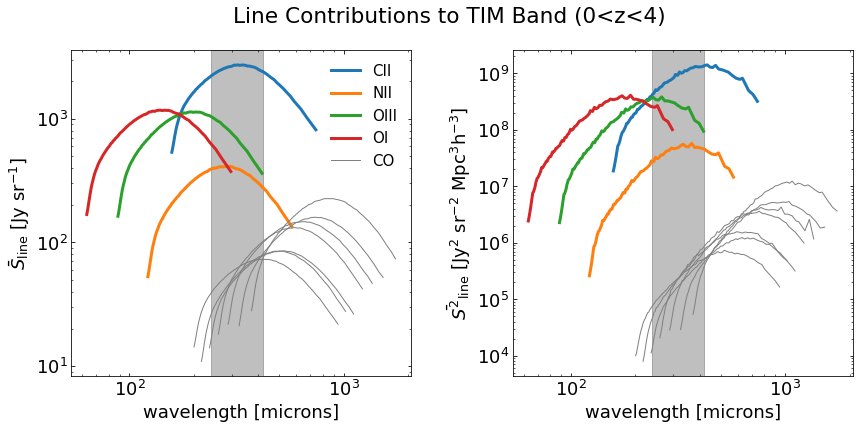

In [6]:
fig,ax = plt.subplots(1,2,figsize=(14,6))
fig.subplots_adjust(wspace=.3)
fig.suptitle('Line Contributions to TIM Band (0<z<4)')
ax[0].set(xlabel='wavelength [microns]',ylabel=r'$\bar{S}_\mathregular{line}$ [Jy sr$^{-1}$]',xscale='log',yscale='log')
ax[1].set(xlabel='wavelength [microns]',ylabel=r'$\bar{S^2}_\mathregular{line}$ [Jy$^2$ sr$^{-2}$ Mpc$^3$h$^{-3}$]',xscale='log',yscale='log')

inds = np.nonzero(z_vals<4)

names = ['LCII_s12','LNII_s12','LOIII_s12','LOI_s12'] + ['LCO{}'.format(i) for i in range(7,14)]
labels = ['CII','NII','OIII','OI','CO'] + [None for i in range(8,14)]
colors = ['C0','C1','C2','C3'] + ['.5' for i in range(7,14)]
wavelengths = [wl_cii,wl_nii,wl_oiii,wl_oi,wl_co7,wl_co8,wl_co9,wl_co10,wl_co11,wl_co12,wl_co13]
lines = ['-' for i in range(len(names))]
linewidths = [3 for i in range(4)] + [1 for i in range(7,14)]

for name, label, color, line, linewidth, wl in zip(names,labels,colors,lines,linewidths,wavelengths):
    ax[0].plot(wl*(1+z_vals[inds])*1e6, np.array(m1_vals[name])[inds],label=label,color=color,linewidth=linewidth,linestyle=line)
    ax[1].plot(wl*(1+z_vals[inds])*1e6, np.array(m2_vals[name])[inds],color=color,linewidth=linewidth,linestyle=line)

ax[0].axvspan(240,420,color='k',alpha=.25)
ax[1].axvspan(240,420,color='k',alpha=.25)
ax[0].legend(fontsize='small')

plt.show()

The above figure shows the first and second moments - in units relevant to LIM observables -
of various line species at a range of wavelengths, corresponding to a range of redshifts for
the line emitters. Here we use the Spinoglio et al. fits for the FIR lines and the Kamenetzky
fits for the CO lines. The curves run from z=0 on the left to z=4 on the right.

We see that, as expected, CII dominates the observed mean intensity across the TIM band. For
the shot power, this model suggests that OIII will produce comparable signal to CII at short
wavelenghts, but that CII will be the dominant signal across most of the band. The shot power
is quite sensitive to the scatter included in the model, with larger scatter parameters increasing
the shot power at fixed mean intensity.

OIII is the next brightest line in the TIM band. NII is about a factor of 10 fainter than CII,
but because it originates from a similar redshift range to CII is a candidate for cross correlation
with both the CII emission itself and galaxy catalogs.

CO lines individually provide a negligible contribution, although the presence of many lines across
the TIM band means that their total contribution to the mean intensity may be comparable NII, 
particularly if lines of higher J than those included here (CO(7-6) through CO(13-12)) remain
excited.

Next we investigate how different prescriptions for the FIR lines alter our results:

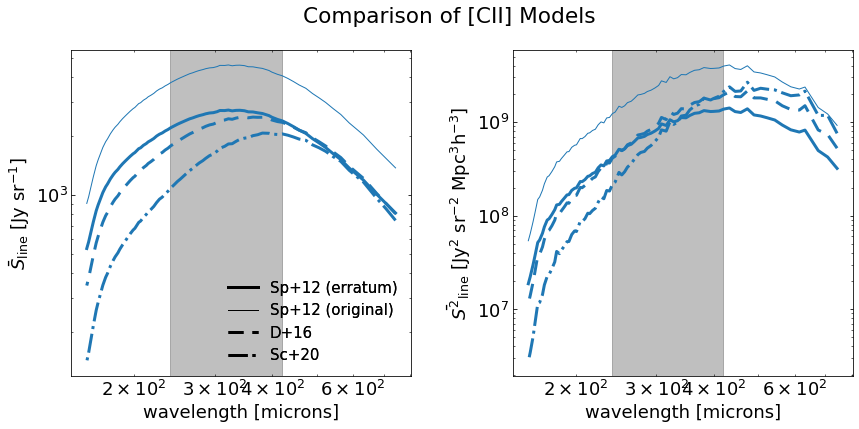

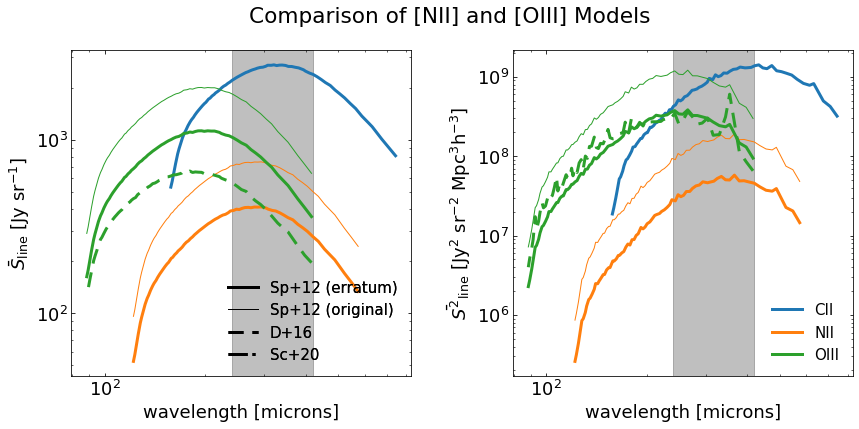

In [7]:
fig,ax = plt.subplots(1,2,figsize=(14,6))
fig.subplots_adjust(wspace=.3)
fig.suptitle('Comparison of [CII] Models')
ax[0].set(xlabel='wavelength [microns]',ylabel=r'$\bar{S}_\mathregular{line}$ [Jy sr$^{-1}$]',xscale='log',yscale='log')
ax[1].set(xlabel='wavelength [microns]',ylabel=r'$\bar{S^2}_\mathregular{line}$ [Jy$^2$ sr$^{-2}$ Mpc$^3$h$^{-3}$]',xscale='log',yscale='log')

inds = np.nonzero(z_vals<4)

names = ['LCII_s12','LCII_u14','LCII_d16','LCII_sch20']
labels = ['Sp+12 (corrected)','Sp+12 (original)','D+16','Sc+20']
colors = ['C0' for i in range(len(names))]
wavelengths = [wl_cii for i in range(len(names))]
lines = ['-','-','--','-.']
linewidths = [3,1,3,3]

for name, label, color, line, linewidth, wl in zip(names,labels,colors,lines,linewidths,wavelengths):
    ax[0].plot(wl*(1+z_vals[inds])*1e6, np.array(m1_vals[name])[inds],label=label,color=color,linewidth=linewidth,linestyle=line)
    ax[1].plot(wl*(1+z_vals[inds])*1e6, np.array(m2_vals[name])[inds],color=color,linewidth=linewidth,linestyle=line)

ax[0].axvspan(240,420,color='k',alpha=.25)
ax[1].axvspan(240,420,color='k',alpha=.25)

h_s12, = plt.plot([],[],'k-',lw=3,label='Sp+12 (erratum)')
h_u14, = plt.plot([],[],'k-',lw=1,label='Sp+12 (original)')
h_d16, = plt.plot([],[],'k--',lw=3,label='D+16')
h_s20, = plt.plot([],[],'k-.',lw=3,label='Sc+20')
l1 = ax[0].legend(fontsize='small',handles=[h_s12,h_u14,h_d16,h_s20],loc='lower right')
ax[0].add_artist(l1)



fig,ax = plt.subplots(1,2,figsize=(14,6))
fig.subplots_adjust(wspace=.3)
fig.suptitle('Comparison of [NII] and [OIII] Models')
ax[0].set(xlabel='wavelength [microns]',ylabel=r'$\bar{S}_\mathregular{line}$ [Jy sr$^{-1}$]',xscale='log',yscale='log')
ax[1].set(xlabel='wavelength [microns]',ylabel=r'$\bar{S^2}_\mathregular{line}$ [Jy$^2$ sr$^{-2}$ Mpc$^3$h$^{-3}$]',xscale='log',yscale='log')

inds = np.nonzero(z_vals<4)

names = ['LCII_s12','LNII_s12','LNII_u14','LOIII_s12','LOIII_u14','LOIII_d16']
labels1 = [None,None,None,'Sp+12 (corrected)','Sp+12 (original)','D+16']
labels2 = ['CII','NII',None,'OIII',None,None,None]
colors = ['C0','C1','C1','C2','C2','C2']
wavelengths = [wl_cii,wl_nii,wl_nii,wl_oiii,wl_oiii,wl_oiii]
lines = ['-','-','-','-','-','--']
linewidths = [3,3,1,3,1,3]

for name, label1, label2, color, line, linewidth, wl in zip(names,labels1,labels2,colors,lines,linewidths,wavelengths):
    ax[0].plot(wl*(1+z_vals[inds])*1e6, np.array(m1_vals[name])[inds],label=label1,color=color,linewidth=linewidth,linestyle=line)
    ax[1].plot(wl*(1+z_vals[inds])*1e6, np.array(m2_vals[name])[inds],label=label2,color=color,linewidth=linewidth,linestyle=line)

ax[0].axvspan(240,420,color='k',alpha=.25)
ax[1].axvspan(240,420,color='k',alpha=.25)
l1 = ax[0].legend(fontsize='small',handles=[h_s12,h_u14,h_d16,h_s20],loc='lower right')
ax[1].legend(fontsize='small')
ax[0].add_artist(l1)

plt.show()

The first of the above plots compares the CII prescriptions of Spinoglio, DeLooze, and Schaerer. 
Also shown are the original Spinoglio, as used in the Uzgil TIM forecast. 

All models show a factor of ~2(4) reduction in the expected first(second) moment, as compared to the original
Uzgil forecasts, although note that the revised star formation history in these mocks compared to the 
Betharmin et al. 2011 history used in Uzgil et al. results in an increased signal for all models at
high redshift.. The revised Spinoglio and DeLooze models produce very comparable predictions
for both the first and second moments, while the Schaerer forecast gives slightly lower mean
first moments, but comparable second moment values.

For the NII and OIII lines we see a similar factor of 2 drop between the Uzgil forecasts and the
revised Spinoglio fits. For OIII the DeLooze fits produce even lower first moments, by another
factor of ~2. Interestingly the DeLooze model produces a second moments comparable to the Spinoglio
model, despite the lower first moment. This is because the DeLooze OIII model has an intrinsic scatter
of ~0.7 dex, compared to the 0.4 dex we assume for the Spinoglio model. The DeLooze fits to the intrinsic
scatter of other lines (CII and OI) show a smaller intrinsic scatter, as do their fits to sub-sets of 
the OIII data. It therefore seems likely that this 0.7 dex scatter is too large. Reducing it to match
the other models would produce lower forecasts for the second moment.

Now we compute the full luminosity functions for our models. We will again 
convert these to observed units, as this will make it easier to evaluate the
sensitivity of TIM.

In [8]:
# Function to compute luminosity functions
def lf_func(lline,redshift,cosmo,box_edge,dlogl=.1,loglmin=3,orders=8):

    # dl = cosmo.luminosity_distance(redshift).value
    # flux_conv = 3.828e26 / (4*np.pi*dl**2) / (3.0857e22)**2 # Lsun --> W / m^2

    nbins = int(orders//dlogl)
    edges = np.array([10**(loglmin+i*dlogl) for i in range(nbins+1)])
    centers = np.array([10**(loglmin+(i+0.5)*dlogl) for i in range(nbins)])
    df = np.zeros(len(centers))

    df,edges = np.histogram(lline,bins=edges)

    df = df/dlogl/(box_edge/(cosmo.H0.value/100))**3

    vals = np.vstack((centers,df))
    return vals

In [9]:
names = ['LCII_s12','LNII_s12','LOIII_s12','LOI_s12',
         'LCII_d16','LOIII_d16','LOI_d16',
         'LCII_sch20',
         'LCII_u14','LNII_u14','LOIII_u14','LOI_u14']

lf_vals = {}
for name in names:
    lf, z_vals = simhandler.snap_stat(lf_func,kwargs=['lline','redshift','cosmo','box_edge'],kw_remap={'lline':name})
    lf_vals[name] = lf
z_vals = np.array(z_vals)

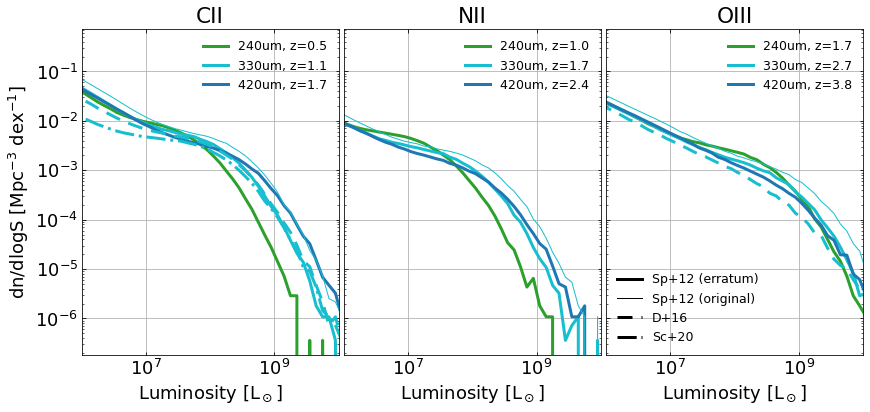

In [10]:
fig,axes = plt.subplots(1,3,figsize=(14,6),sharex=True,sharey=True)
fig.subplots_adjust(wspace=.02)
for ax in axes:
    ax.set(xlabel='Luminosity [L$_\odot$]',xscale='log',yscale='log',xlim=(1e6,1e10))
    ax.grid()
axes[0].set(title='CII',ylabel=r'dn/d$\log$S [Mpc$^{-3}$ dex$^{-1}$]')
axes[1].set(title='NII')
axes[2].set(title='OIII')

names = ['LCII_s12','LNII_s12','LOIII_s12']
axuse = [axes[0],axes[1],axes[2]]
lines = ['-','-','-']
linewidths = [3,3,3]
wavelenghts = [wl_cii,wl_nii,wl_oiii]

obs_wavelengths = [240e-6,330e-6,420e-6]
obs_wl_colors = ['C2','C9','C0']

for name, ax, line, linewidth, wl in zip(names,axuse,lines,linewidths,wavelenghts):
    for obs_wl, color in zip(obs_wavelengths,obs_wl_colors):
        snap_id = simhandler.z_to_snap(obs_wl/wl-1)
        ax.plot(lf_vals[name][snap_id][0],lf_vals[name][snap_id][1],color=color,label="{:.0f}um, z={:.1f}".format(obs_wl*1e6,obs_wl/wl-1),linewidth=linewidth,linestyle=line)

names = ['LCII_u14','LCII_d16','LCII_sch20','LNII_u14','LOIII_u14','LOIII_d16']
axuse = [axes[0],axes[0],axes[0],axes[1],axes[2],axes[2]]
lines = ['-','--','-.','-','-','--']
linewidths = [1,3,3,1,1,3]
wavelenghts = [wl_cii,wl_cii,wl_cii,wl_nii,wl_oiii,wl_oiii]

obs_wavelengths = [330e-6,]
obs_wl_colors = ['C9']

for name, ax, line, linewidth, wl in zip(names,axuse,lines,linewidths,wavelenghts):
    for obs_wl, color in zip(obs_wavelengths,obs_wl_colors):
        snap_id = simhandler.z_to_snap(obs_wl/wl-1)
        ax.plot(lf_vals[name][snap_id][0],lf_vals[name][snap_id][1],color=color,linewidth=linewidth,linestyle=line)


l1 = axes[2].legend(fontsize='x-small',handles=[h_s12,h_u14,h_d16,h_s20],loc='lower left')
for ax in axes:
    ax.legend(fontsize='x-small')
axes[2].add_artist(l1)


plt.show()

The above figure shows luminosity functions for CII, NII, and OIII at the edges 
and midpoint of the TIM band (denoted by colors) for the Spinoglio model. For the 
midband, we also show the DeLooze CII and OIII models and the Schaerer CII model.

## Comparison to IR Luminosity Function Approach

Uzgil et al. 2014 constructed models by taking weighted integrals over analytical representations
of the IR luminosity function, in place of summing over halo catalogs. This approach
has the advantage of computational simplicity. On the other hand, our simulation/halo
catalog based approach makes it possible to generate mocks which can be used to test
data pipelines and validate survey strategy in a way that the analytical approach 
cannot.

Here we perform a consistency check between the our approach and the IR luminosity function
based approach. Our method generates SFRs for each halo based on the prescription of
Behroozi et al. 2013, which is in turn calibrated to reproduce the observed star formation
rate density (SFRD) of the universe. Integrating the IR luminosity function is one way of constraining
the SFRD, and so we should expect these two methods to produce comparable results.

We begin by comparing implementing the analytical IR luminosity function of Betharmin et al.
2011 (the LF used in Uzgil et al.).


In [11]:
# Betharmine LF
beta = 1.223
xi = 0.406

def Lstar(z):
    if z<0.879:
        return 2.377e10*(1+z)**2.931
    elif z<2.0:
        p0 = 2.377e10*(1.879)**2.931
        return p0 * ((1+z)/1.879)**4.737
    else:
        p0 = 2.377e10 * (1.879)**2.931 * (3/1.879)**4.737
        return p0 * ((1+z)/3.0)**0.145

def Phistar(z):
    if z<0.879:
        return 3.234e-3*(1+z)**0.774
    elif z<2.0:
        p0 = 3.234e-3*(1.879)**0.774
        return p0 * ((1+z)/1.879)**-6.246
    else:
        p0 = 3.234e-3 * (1.879)**0.774 * ((3)/1.879)**-6.246
        return p0 * ((1+z)/3.0)**-0.919

def irlf_b11(L,z):
    Ls = Lstar(z)
    Ps = Phistar(z)
    return Ps * (L/Ls)**(1-beta) * np.exp(-1/(2*xi**2)*np.log10(1+L/Ls)**2)


Now we can compute the IR luminosity density or star formation rate density
history for both the Betharmin et al. model and for our simulation boxes

In [12]:
# Compute the IRLF and SFRD of the sim boxes - for the IRLF we'll simply use the 
# distribution of SFRs, but with the x axis rescaled by 1e10 (the conversion factor
# between IR luminosity and SFR for a Chambrier IMF)
def sfrd(sfr,cosmo,box_edge):

    h = cosmo.H0.value/100
    V = (box_edge/h)**3
    return np.sum(sfr/V)

sfrd_sim, _ = simhandler.snap_stat(sfrd,kwargs=['sfr','cosmo','box_edge'],kw_remap={'sfr':'sfr_behroozi'})
irlf_sim, _ = simhandler.snap_stat(lf_func,kwargs=['lline','redshift','cosmo','box_edge'],kw_remap={'lline':'sfr_behroozi'},other_kws={'loglmin':-4})

for i in range(len(irlf_sim)):
    irlf_sim[i][0] = irlf_sim[i][0] / 1.0e-10

# Compute the SFRD from the Betharmin LF
z_b11 = np.linspace(0,4,41)
l = np.logspace(8,14,61)
sfrd_b11 = np.zeros(len(z_b11))
for i in range(len(z_b11)):
    lf = irlf_b11(l,z_b11[i])
    sfrd_b11[i] = np.sum(l*lf*0.1) * 1.0e-10

# Compute SFRD for Madau and Dickinson
sfrd_md13 = 0.015 * (1+z_b11)**2.7 / (1+((1+z_b11)/2.9)**5.6)

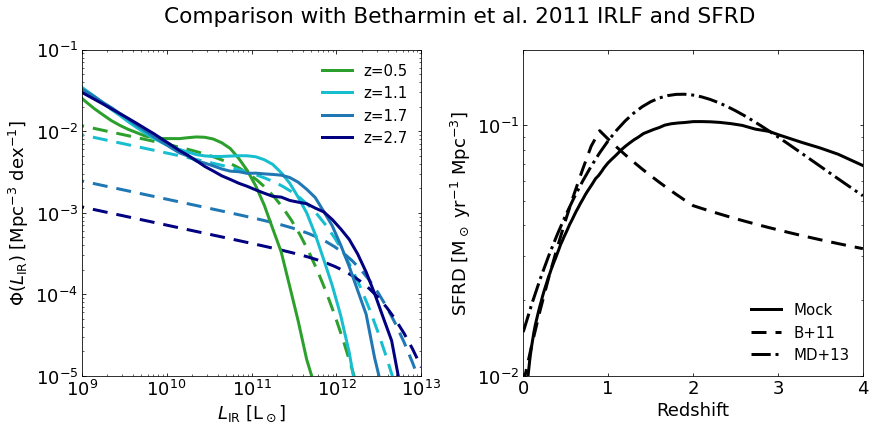

In [13]:
fig,ax = plt.subplots(1,2,figsize=(14,6))
fig.subplots_adjust(wspace=.3)
fig.suptitle('Comparison with Betharmin et al. 2011 IRLF and SFRD')
ax[0].set(xlabel='$L_\mathregular{IR}$ [L$_\odot$]',ylabel='$\Phi(L_\mathregular{IR})$ [Mpc$^{-3}$ dex$^{-1}$]',xscale='log',yscale='log',xlim=(1e9,1e13),ylim=(1e-5,.1))
ax[1].set(xlabel='Redshift',ylabel='SFRD [M$_\odot$ yr$^{-1}$ Mpc$^{-3}$]',yscale='log',xlim=(0,4),ylim=(.01,.2))

redshifts = [0.5,1.1,1.7,2.7]
colors = ['C2','C9','C0','navy']

# Plot Betharmin LFs:
L = np.logspace(8,13)
for z, color in zip(redshifts,colors):
    ax[0].plot(L,irlf_b11(L,z),color=color,lw=3,linestyle='--')

# Plot Mock LFs:
for z, color in zip(redshifts,colors):
    snap_id = simhandler.z_to_snap(z)
    ax[0].plot(irlf_sim[snap_id][0],irlf_sim[snap_id][1],color=color,linewidth=3,linestyle='-',label='z={:.1f}'.format(z))

# Plot histories:
ax[1].plot(z_vals,sfrd_sim,lw=3,color='k',ls='-',label='Mock')
ax[1].plot(z_b11,sfrd_b11,lw=3,color='k',ls='--',label='B+11')
ax[1].plot(z_b11,sfrd_md13,lw=3,color='k',ls='-.',label='MD+13')

ax[0].legend(fontsize='small')
ax[1].legend(fontsize='small')

plt.show()


In the above figure we show the star formation histories produced by our SimIM mock and 
the Betharmin et al. 2011 LFs, along with the fit to a compilation of data provided
in Madau and Dickinson 2013. All three histories agree up to z~1, however the Betharmin
model has a sharp downturn after this point, while the SimIM mock and the Madau and 
Dickinson fits peak at redshift ~2 before rolling off at higher redshifts. We can
therefore expect the forecast from our mocks to agree with the Uzgil et al. 
approach (modulo the correction to the Spinoglio scaling relations) up to z~1, but 
disagree at higher redshifts, with the simulation favioring stronger signals above z=1.
The same broad agreement between our mock and the Betharmin IR LFs up to z~1 can be
seen in the luminosity functions plotted on the left. However, at z>1 there is a steep 
decline in the normalization of the Betharmin LFs that is not matched by our simulations.
This explains the falling SFRD at z>1 for the Betharmine model.

All three SFR measurements shown here are somewhat outdated, and more recent data on
the SFRD is available. It may be worthwhile to update our star formation models to
include results from the last decade. However the peak in SFRD at z~2 is fairly robust
and the results of recent studies tend to focus on extending measurements to higher
redshifts which aren't of great importance to TIM. The good agreement between our 
mocks and the Madau and Dickinson fit - based on a compilation of UV and infrared
studies - leads us to conclude that the mock used here is adequate for rough forecasts
of the TIM signal.

*Note: we need to check the consistency of $L_{IR}$ to SFR conversion factors being 
used between the three models. Behroozi assumes Chambrier IMF, which should have
$\mathrm{SFR} = 1.0\times10^{-10} L_{IR}$. I've used this conversion factor for computing
the SFRD from the Betharmin model, and it is assumed in calculating line luminosities
for the Spinoglio and Kamenetzky models. Madau uses $\mathrm{SFR} = 1.7\times10^{-10} L_{IR}$.

Next we can compare forecasts for moments of the FIR luminosity functions. This provides
a way to compare the results from Uzgil et al. 2014 with the new model implemented here.

In [14]:
from simim.lineprops.farinfrared import spinoglio12, uzgil14

# Function to compute the moments of the line luminosity functions
# for the Betharmin et al. 2011 IRLFs. This reproduces the 
def sline_analytic(line='[CII]',cosmo=simhandler.cosmo,corrected=True):
    za = np.linspace(0,4,41)
    lir = np.logspace(8,14,61)
    s_analytic = np.zeros(len(za))
    s2_analytic = np.zeros(len(za))

    for i in range(len(za)):
        lf = irlf_b11(l,za[i])
        if corrected:
            lline = spinoglio12(l*1.0e-10,line=line,scatter=False)
        else:
            lline = uzgil14(l*1.0e-10,line=line,scatter=False)
        
        d = cosmo.comoving_distance(za[i]).value       # comoing distance at z in Mpc
        dl = (1+za[i])*d                               # luminosity distance to z in Mpc
        y = wl_cii * (1+za[i])**2 / (1000*cosmo.H(za[i]).value)  # derivative of distance with respect to frequency in Mpc / Hz

        m1 = np.sum(lf*lline*0.1)
        s_line = m1 / (4*np.pi*dl**2) * d**2 * y          # in Lsun / Mpc^2 * Mpc^2/Sr * Mpc/Hz
        s_line = s_line * 3.828e26                        # in W / Sr / Mpc^2 / Hz
        s_line = s_line / (3.0857e22)**2                  # in W / Sr / m^2 / Hz
        s_line = 1e26 * s_line                            # in Jy/Sr
        s_analytic[i] = s_line

        m2 = np.sum(lf*lline**2*0.1)
        s2_line = m2 / (4*np.pi*dl**2)**2 * (d**2*y)**2     # in Lsun^2/Mpc^3 / Mpc^4 * Mpc^4/Sr^2 * Mpc^2/Hz^2 = Lsun^2/Sr^2/Hz^2 / Mpc 
        s2_line = s2_line * 3.828e26  **2                   # in W^2/Sr^2/Hz^2 / Mpc = W^2/Sr^2/Hz^2 / Mpc^4 * Mpc^3
        s2_line = s2_line / (3.0857e22)**4                  # in W^2/Sr^2/Hz^2/m^4 * Mpc^3
        s2_line = 1e26**2 * s2_line                         # in Jy^2/Sr^2 Mpc^3
        s2_line = s2_line * (cosmo.H0.value/100)**3         # in Jy^2/Sr^2 (Mpc/h)^3
        s2_analytic[i] = s2_line

    return s_analytic,s2_analytic

In [15]:
# Evaluate the first and second moments for selected lines
z_b11 = np.linspace(0,4,41)

lines = ['[CII]','[NII]','[OIII]88um','[OI]','[CII]','[NII]','[OIII]88um','[OI]']
keys = ['LCII_s12','LNII_s12','LOIII_s12','LOI_s12','LCII_u14','LNII_u14','LOIII_u14','LOI_u14']

m1_analytic = {}
m2_analytic = {}

for line, key in zip(lines,keys):
    if key[-3:] == 'u14':
        corrected = False
    else:
        corrected = True
    s1,s2 = sline_analytic(line=line,corrected=corrected)
    m1_analytic[key] = s1
    m2_analytic[key] = s2


<ipython-input-14-2cd816ba4beb>:23: RuntimeWarning: divide by zero encountered in double_scalars
  s_line = m1 / (4*np.pi*dl**2) * d**2 * y          # in Lsun / Mpc^2 * Mpc^2/Sr * Mpc/Hz
<ipython-input-14-2cd816ba4beb>:23: RuntimeWarning: invalid value encountered in double_scalars
  s_line = m1 / (4*np.pi*dl**2) * d**2 * y          # in Lsun / Mpc^2 * Mpc^2/Sr * Mpc/Hz
<ipython-input-14-2cd816ba4beb>:30: RuntimeWarning: divide by zero encountered in double_scalars
  s2_line = m2 / (4*np.pi*dl**2)**2 * (d**2*y)**2     # in Lsun^2/Mpc^3 / Mpc^4 * Mpc^4/Sr^2 * Mpc^2/Hz^2 = Lsun^2/Sr^2/Hz^2 / Mpc
<ipython-input-14-2cd816ba4beb>:30: RuntimeWarning: invalid value encountered in double_scalars
  s2_line = m2 / (4*np.pi*dl**2)**2 * (d**2*y)**2     # in Lsun^2/Mpc^3 / Mpc^4 * Mpc^4/Sr^2 * Mpc^2/Hz^2 = Lsun^2/Sr^2/Hz^2 / Mpc


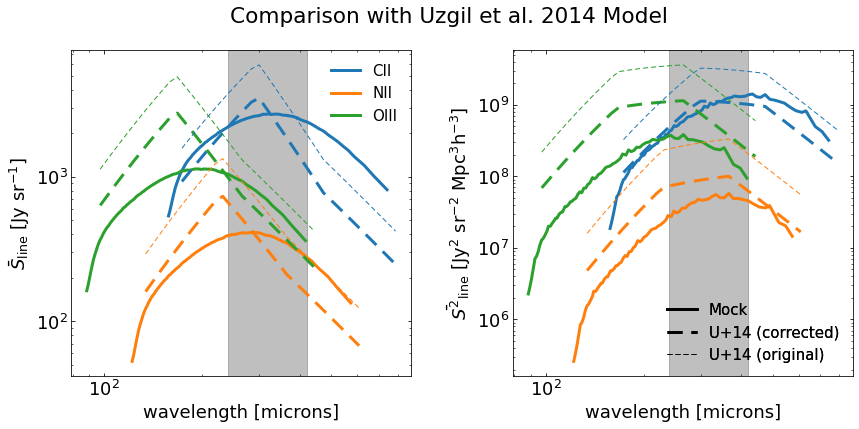

In [16]:
fig,ax = plt.subplots(1,2,figsize=(14,6))
fig.subplots_adjust(wspace=.3)
fig.suptitle('Comparison with Uzgil et al. 2014 Model')
ax[0].set(xlabel='wavelength [microns]',ylabel=r'$\bar{S}_\mathregular{line}$ [Jy sr$^{-1}$]',xscale='log',yscale='log')
ax[1].set(xlabel='wavelength [microns]',ylabel=r'$\bar{S^2}_\mathregular{line}$ [Jy$^2$ sr$^{-2}$ Mpc$^3$h$^{-3}$]',xscale='log',yscale='log')

inds = np.nonzero(z_vals<4)

names = ['LCII_s12','LNII_s12','LOIII_s12']
labels = ['CII','NII','OIII']
colors = ['C0','C1','C2']
wavelengths = [wl_cii,wl_nii,wl_oiii]
lines = ['-' for i in range(len(names))]
linewidths = [3 for i in range(3)]

for name, label, color, line, linewidth, wl in zip(names,labels,colors,lines,linewidths,wavelengths):
    ax[0].plot(wl*(1+z_vals[inds])*1e6, np.array(m1_vals[name])[inds],color=color,linewidth=linewidth,linestyle=line,label=label)
    ax[1].plot(wl*(1+z_vals[inds])*1e6, np.array(m2_vals[name])[inds],color=color,linewidth=linewidth,linestyle=line)

lines = ['--' for i in range(len(names))]
for name, label, color, line, linewidth, wl in zip(names,labels,colors,lines,linewidths,wavelengths):
    ax[0].plot(wl*(1+z_b11)*1e6, np.array(m1_analytic[name]),color=color,linewidth=linewidth,linestyle=line)
    ax[1].plot(wl*(1+z_b11)*1e6, np.array(m2_analytic[name]),color=color,linewidth=linewidth,linestyle=line)

names = ['LCII_u14','LNII_u14','LOIII_u14']
linewidths = [1 for i in range(3)]
for name, label, color, line, linewidth, wl in zip(names,labels,colors,lines,linewidths,wavelengths):
    ax[0].plot(wl*(1+z_b11)*1e6, np.array(m1_analytic[name]),color=color,linewidth=linewidth,linestyle=line)
    ax[1].plot(wl*(1+z_b11)*1e6, np.array(m2_analytic[name]),color=color,linewidth=linewidth,linestyle=line)


ax[0].axvspan(240,420,color='k',alpha=.25)
ax[1].axvspan(240,420,color='k',alpha=.25)
ax[0].legend(fontsize='small')

h_new, = plt.plot([],[],'k-',lw=3,label='Mock')
h_old1, = plt.plot([],[],'k--',lw=3,label='U+14 (corrected)')
h_old2, = plt.plot([],[],'k--',lw=1,label='U+14 (original)')
l1 = ax[1].legend(fontsize='small',handles=[h_new,h_old1,h_old2],loc='lower right')
ax[1].add_artist(l1)

## Power Spectrum Forecasts
Next we'll compute actual power spectra for our models. We'll do this
numerically by putting the flux from halo catalogs into a grid and 
computing the fourier transform. To start off, we will simply compute 
the power spectra of individual lines, assuming contamination from 
other lines can be neglected.

In [17]:
from simim.map import gridder

# Function to compute the real-space, noise and contamination free
# power spectrum
def powspec_func(pos_x,pos_y,pos_z,lline,redshift,cosmo,box_edge,wavelength):
    
    if len(pos_x) == 0:
        return None

    h = cosmo.H0.value/100
    d = cosmo.comoving_distance(redshift).value       # comoing distance at z in Mpc
    dl = (1+redshift)*d                               # luminosity distance to z in Mpc
    y = wavelength * (1+redshift)**2 / (1000*cosmo.H(redshift).value)  # derivative of distance with respect to frequency in Mpc / Hz

    pixel_size = 1
    side_length = ((box_edge/h)//pixel_size)*pixel_size   # Cut off the edge of the box if it doesn't match pixel size
    center_point = np.array([side_length/2,side_length/2,side_length/2])

    positions = np.array([pos_x,pos_y,pos_z]).T

    intensities = lline / pixel_size**3 / (4*np.pi*dl**2) * d**2 * y  # in Lsun/Mpc^3 / Mpc^2 * Mpc^2/Sr * Mpc/Hz
    intensities = intensities * 3.828e26 / 3.0857e22**2 *1e26               # in Jy/Sr

    grid = gridder(positions,intensities,center_point=center_point,side_length=side_length,pixel_size=pixel_size,axunits='Mpc',gridunits='Jy/Sr')
    ps = grid.power_spectrum(in_place=False,normalize=False)

    ax1d, ps1d = ps.spherical_average(ax=[0,1,2],bins=np.logspace(-3,1,41))
    kax = 2*np.pi*np.logspace(-3.05,0.95,40) / h
    ps1d = ps1d[:,0] / side_length**3 * h**3

    return np.vstack((kax,ps1d))


In [18]:
names = ['LCII_s12','LNII_s12','LOIII_s12']
wavelenghts = [wl_cii,wl_nii,wl_oiii]

ps_vals = {}
for name, wl in zip(names,wavelenghts):
    ps, z_vals = simhandler.snap_stat(powspec_func,
                                      kwargs=['pos_x','pos_y','pos_z','lline','redshift','cosmo','box_edge'],
                                      kw_remap={'lline':name},other_kws={'wavelength':wl})
    ps_vals[name] = ps
z_vals = np.array(z_vals)

/home/rpkeenan/simim/simim/map/gridder.py:1007: RuntimeWarning: invalid value encountered in true_divide
  binned_averages /= binned_weights


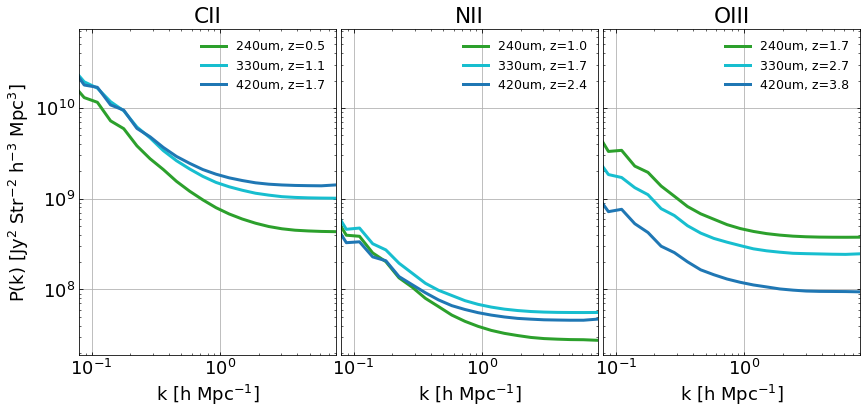

In [19]:
if simname=='TNG300-1':
    xlim = (.08,8)
else:
    xlim = (.2,8)

fig,axes = plt.subplots(1,3,figsize=(14,6),sharex=True,sharey=True)
fig.subplots_adjust(wspace=.02)
for ax in axes:
    ax.set(xlabel='k [h Mpc$^{-1}$]',xscale='log',yscale='log',xlim=xlim)
    ax.grid()
axes[0].set(title='CII',ylabel=r'P(k) [Jy$^2$ Str$^{-2}$ h$^{-3}$ Mpc$^3$]')
axes[1].set(title='NII')
axes[2].set(title='OIII')

names = ['LCII_s12','LNII_s12','LOIII_s12']
axuse = [axes[0],axes[1],axes[2]]
lines = ['-','-','-']
linewidths = [3,3,3]
wavelenghts = [wl_cii,wl_nii,wl_oiii]

obs_wavelengths = [240e-6,330e-6,420e-6]
obs_wl_colors = ['C2','C9','C0']

for name, ax, line, linewidth, wl in zip(names,axuse,lines,linewidths,wavelenghts):
    for obs_wl, color in zip(obs_wavelengths,obs_wl_colors):
        snap_id = simhandler.z_to_snap(obs_wl/wl-1)
        ax.plot(ps_vals[name][snap_id][0],ps_vals[name][snap_id][1],color=color,label="{:.0f}um, z={:.1f}".format(obs_wl*1e6,obs_wl/wl-1),linewidth=linewidth,linestyle=line)

for ax in axes:
    ax.legend(fontsize='x-small',loc='upper right')

plt.show()

## Cross-Correlation Forecasts


We will consider cross correlations between CII and NII, as well as 
between CII or OIII and CO lines from the SPT-SLIM intensity mapping
experiment.

In practice, the covariance between the luminosities of the two lines
will affect the amplitude of our signals. In the assignment of line 
luminosities we originally used the same set of random numbers to draw 
random scatter for both CII and NII, meaning that the offsets of each 
galaxy's line luminosity from the mean relation will correlate perfectly.

A more sophisticated model could accurately account for the covariance
of various lines, but for now we will just bracket the range of possibilities
by drawing a second set of NII luminosities with a different random seed, showing
what would happen if there was no covariance of the offsets.

Note: we did not use the same random number generator seed for CO as the other
models, so our CO x CII and CO x OIII models will all have the minimum covariance.

In [20]:
# Create a second realization of the NII luminosities
# By not specifying an rng in the other_kws parameter, we cause SimIM to 
# generate a new instance with a different seed from the one used before.
simhandler.make_property(prop_spinoglio_fir,rename='LNII_s12_v2',kw_remap={'sfr':'sfr_behroozi'},other_kws={'line':'[NII]','sig_scatter':default_scatter},write=False,overwrite=True)

We now define a function to evaluate the cross-power spectrum for each 
simulation snapshot and run it for the relevant line pairs.

In [21]:
# Function to compute the real-space, noise and contamination free
# power spectrum
def l1_cross_l2_func(pos_x,pos_y,pos_z,l1,l2,redshift,cosmo,box_edge,wavelength1,wavelength2):
    
    if len(pos_x) == 0:
        return None

    h = cosmo.H0.value/100
    d = cosmo.comoving_distance(redshift).value       # comoing distance at z in Mpc
    dl = (1+redshift)*d                               # luminosity distance to z in Mpc
    y1 = wavelength1 * (1+redshift)**2 / (1000*cosmo.H(redshift).value)  # derivative of distance with respect to frequency in Mpc / Hz
    y2 = wavelength2 * (1+redshift)**2 / (1000*cosmo.H(redshift).value)  # derivative of distance with respect to frequency in Mpc / Hz

    pixel_size = 1
    side_length = ((box_edge/h)//pixel_size)*pixel_size   # Cut off the edge of the box if it doesn't match pixel size
    center_point = np.array([side_length/2,side_length/2,side_length/2])

    positions = np.array([pos_x,pos_y,pos_z]).T

    intensities1 = l1 / pixel_size**3 / (4*np.pi*dl**2) * d**2 * y1  # in Lsun/Mpc^3 / Mpc^2 * Mpc^2/Sr * Mpc/Hz
    intensities1 = intensities1 * 3.828e26 / 3.0857e22**2 *1e26               # in Jy/Sr
    intensities2 = l2 / pixel_size**3 / (4*np.pi*dl**2) * d**2 * y2  # in Lsun/Mpc^3 / Mpc^2 * Mpc^2/Sr * Mpc/Hz
    intensities2 = intensities2 * 3.828e26 / 3.0857e22**2 *1e26               # in Jy/Sr

    grid1 = gridder(positions,intensities1,center_point=center_point,side_length=side_length,pixel_size=pixel_size,axunits='Mpc',gridunits='Jy/Sr')
    grid2 = gridder(positions,intensities2,center_point=center_point,side_length=side_length,pixel_size=pixel_size,axunits='Mpc',gridunits='Jy/Sr')
    ps = grid1.power_spectrum(cross_grid=grid2,in_place=False,normalize=False)

    ax1d, ps1d = ps.spherical_average(ax=[0,1,2],bins=np.logspace(-3,1,41))
    kax = 2*np.pi*np.logspace(-3.05,0.95,40) / (cosmo.H0.value/100)
    ps1d = ps1d[:,0] / side_length**3 * (cosmo.H0.value/100)**3

    return np.vstack((kax,ps1d))

cii_x_nii, z_vals = simhandler.snap_stat(l1_cross_l2_func,
                                         kwargs=['pos_x','pos_y','pos_z','l1','l2','redshift','cosmo','box_edge'],
                                         kw_remap={'l1':'LCII_s12','l2':'LNII_s12'},other_kws={'wavelength1':wl_cii,'wavelength2':wl_nii})
cii_x_nii_v2, z_vals = simhandler.snap_stat(l1_cross_l2_func,
                                         kwargs=['pos_x','pos_y','pos_z','l1','l2','redshift','cosmo','box_edge'],
                                         kw_remap={'l1':'LCII_s12','l2':'LNII_s12_v2'},other_kws={'wavelength1':wl_cii,'wavelength2':wl_nii})
cii_x_co2, z_vals = simhandler.snap_stat(l1_cross_l2_func,
                                         kwargs=['pos_x','pos_y','pos_z','l1','l2','redshift','cosmo','box_edge'],
                                         kw_remap={'l1':'LCII_s12','l2':'LCO2'},other_kws={'wavelength1':wl_cii,'wavelength2':wl_co2})
cii_x_co3, z_vals = simhandler.snap_stat(l1_cross_l2_func,
                                         kwargs=['pos_x','pos_y','pos_z','l1','l2','redshift','cosmo','box_edge'],
                                         kw_remap={'l1':'LCII_s12','l2':'LCO3'},other_kws={'wavelength1':wl_cii,'wavelength2':wl_co3})
oiii_x_co4, z_vals = simhandler.snap_stat(l1_cross_l2_func,
                                         kwargs=['pos_x','pos_y','pos_z','l1','l2','redshift','cosmo','box_edge'],
                                         kw_remap={'l1':'LOIII_s12','l2':'LCO4'},other_kws={'wavelength1':wl_oiii,'wavelength2':wl_co4})
oiii_x_co5, z_vals = simhandler.snap_stat(l1_cross_l2_func,
                                         kwargs=['pos_x','pos_y','pos_z','l1','l2','redshift','cosmo','box_edge'],
                                         kw_remap={'l1':'LOIII_s12','l2':'LCO5'},other_kws={'wavelength1':wl_oiii,'wavelength2':wl_co5})
oiii_x_co6, z_vals = simhandler.snap_stat(l1_cross_l2_func,
                                         kwargs=['pos_x','pos_y','pos_z','l1','l2','redshift','cosmo','box_edge'],
                                         kw_remap={'l1':'LOIII_s12','l2':'LCO6'},other_kws={'wavelength1':wl_oiii,'wavelength2':wl_co6})
z_vals = np.array(z_vals)


/home/rpkeenan/simim/simim/map/gridder.py:1007: RuntimeWarning: invalid value encountered in true_divide
  binned_averages /= binned_weights


We are also interested in the cross-correlation of TIM's data cube with
catalogs of galaxies with known spectroscopic redshifts. Modeling this requires
an esitmate of the number density of galaxies in our cross-correlation field (GOODS-South),
as well as a knowledge of the selection function for those galaxies and the resulting
FIR line luminosities of the galaxy catalog. 

Much work could go into modeling this rigorously, here we will construct a simple model
to get a general sense for what can be expected.

For the number density of galaxies, we use the results from 3DHST to estimate that there
are 1500 grism redshifts available from z=0.5 to z=1.0 in GOODS-S, resulting in a number
density of n~0.005 Mpc$^{-3}$ for the catalog to be cross correlated with CII. For the OIII
catalog we use the same results to estimate that there are 500 grism redshifts from z=2.0 to
z=3.0, resulting in a number density of n~0.0004 Mpc$^{-3}$.

For the selection function, we assume that the 3DHST grism spectra simply correspond to
the most massive halos in the field, and so select all galaxies in halos above some cutoff
in the halo mass distribution function that matches our desired number density.

In [22]:
# Function to compute the line-galaxy cross power spectrum. n is a number density and
# will be used to select galaxies by integrating the cumulative halo mass function until
# n is reached.
def l1_cross_ngal_func(pos_x,pos_y,pos_z,l1,mass,n,redshift,cosmo,box_edge,wavelength1):
    
    if len(pos_x) == 0:
        return None

    h = cosmo.H0.value/100
    V = (box_edge/h)**3
    if len(mass)/V < n: # If snapshot doesn't contain enough halos
        return None

    N = np.ceil(n*V).astype(int)
    inds_sorted = np.argsort(-mass) # invert m so the first index will be the most massive halo
    inds_use = inds_sorted[:N]
    
    d = cosmo.comoving_distance(redshift).value       # comoing distance at z in Mpc
    dl = (1+redshift)*d                               # luminosity distance to z in Mpc
    y1 = wavelength1 * (1+redshift)**2 / (1000*cosmo.H(redshift).value)  # derivative of distance with respect to frequency in Mpc / Hz

    pixel_size = 1
    side_length = ((box_edge/h)//pixel_size)*pixel_size   # Cut off the edge of the box if it doesn't match pixel size
    center_point = np.array([side_length/2,side_length/2,side_length/2])

    positions = np.array([pos_x,pos_y,pos_z]).T

    intensities1 = l1 / pixel_size**3 / (4*np.pi*dl**2) * d**2 * y1  # in Lsun/Mpc^3 / Mpc^2 * Mpc^2/Sr * Mpc/Hz
    intensities1 = intensities1 * 3.828e26 / 3.0857e22**2 *1e26               # in Jy/Sr

    grid1 = gridder(positions,intensities1,center_point=center_point,side_length=side_length,pixel_size=pixel_size,axunits='Mpc',gridunits='Jy/Sr')
    grid2 = gridder(positions[inds_use],center_point=center_point,side_length=side_length,pixel_size=pixel_size,axunits='Mpc',gridunits='Mpc^-3')
    grid2.grid = grid2.grid / np.mean(grid2.grid) - 1
    ps = grid1.power_spectrum(cross_grid=grid2,in_place=False,normalize=False)

    ax1d, ps1d = ps.spherical_average(ax=[0,1,2],bins=np.logspace(-3,1,41))
    kax = 2*np.pi*np.logspace(-3.05,0.95,40) / (cosmo.H0.value/100)
    ps1d = ps1d[:,0] / side_length**3 * (cosmo.H0.value/100)**3

    return np.vstack((kax,ps1d))

# GOODS-S has ~1500 grism redshifts from z=0.5 to z=1.0. 
# The area of GOODS-S is ~0.1 square degree. The total
# comoving volume betwee these redshifts is about 128.6 Gpc^3.
# The volume of GOODS-S works out to be 300,000 Mpc^3. So 
# the number density is about 0.005 Mpc^-3.
# Note the number of spec-zs is about 1/3 the number of 
# grism-zs. 
cii_x_gal, z_vals = simhandler.snap_stat(l1_cross_ngal_func,
                                            kwargs=['pos_x','pos_y','pos_z','l1','mass','redshift','cosmo','box_edge'],
                                            kw_remap={'l1':'LCII_s12'},other_kws={'wavelength1':wl_cii,'n':0.005})

# GOODS-S has ~500 grism redshifts from z=2 to z=3. 
# The volume of the whole sky between these redshifts 
# is ~526 Gpc^3. The volume of GOODS-S is ~1,300,000 Mpc^3
# so the number density is about 0.0004
oiii_x_gal, z_vals = simhandler.snap_stat(l1_cross_ngal_func,
                                            kwargs=['pos_x','pos_y','pos_z','l1','mass','redshift','cosmo','box_edge'],
                                            kw_remap={'l1':'LOIII_s12'},other_kws={'wavelength1':wl_oiii,'n':0.0004})
z_vals = np.array(z_vals)


We will also consider a few simple variations of the model, in order to explore
how changes to our simple estimates and assumptions might impact the expected signal.

We consider the following additional models:
- Reduced number density - if grism redshifts aren't suitable for cross correlation
analysis and only higher resolution spectra can be used, we will have a lower number
density catalog to cross correlate with. We estimate that using spectroscopic redshifts 
reduces our catalog size by about 67% for CII, and 50% for OIII.
- Altered selection function - we also consider a catalog using the galaxies
with the highest SFR instead of the highest halo mass. This represents a selection
function that (in our model) picks galaxies with higher mean FIR line luminosity.

In [23]:
# Lower number density catalogs:
cii_x_gal_lown, z_vals = simhandler.snap_stat(l1_cross_ngal_func,
                                            kwargs=['pos_x','pos_y','pos_z','l1','mass','redshift','cosmo','box_edge'],
                                            kw_remap={'l1':'LCII_s12'},other_kws={'wavelength1':wl_cii,'n':0.005/3})

oiii_x_gal_lown, z_vals = simhandler.snap_stat(l1_cross_ngal_func,
                                            kwargs=['pos_x','pos_y','pos_z','l1','mass','redshift','cosmo','box_edge'],
                                            kw_remap={'l1':'LOIII_s12'},other_kws={'wavelength1':wl_oiii,'n':0.0004/2})

# SFR selected catalogs:
cii_x_gal_sfr, z_vals = simhandler.snap_stat(l1_cross_ngal_func,
                                            kwargs=['pos_x','pos_y','pos_z','l1','mass','redshift','cosmo','box_edge'],
                                            kw_remap={'l1':'LCII_s12','mass':'sfr_behroozi'},other_kws={'wavelength1':wl_cii,'n':0.005})

oiii_x_gal_sfr, z_vals = simhandler.snap_stat(l1_cross_ngal_func,
                                            kwargs=['pos_x','pos_y','pos_z','l1','mass','redshift','cosmo','box_edge'],
                                            kw_remap={'l1':'LOIII_s12','mass':'sfr_behroozi'},other_kws={'wavelength1':wl_oiii,'n':0.0004})


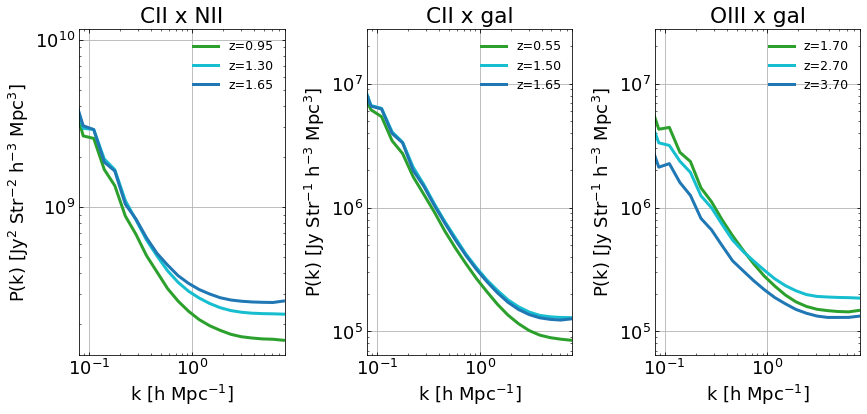

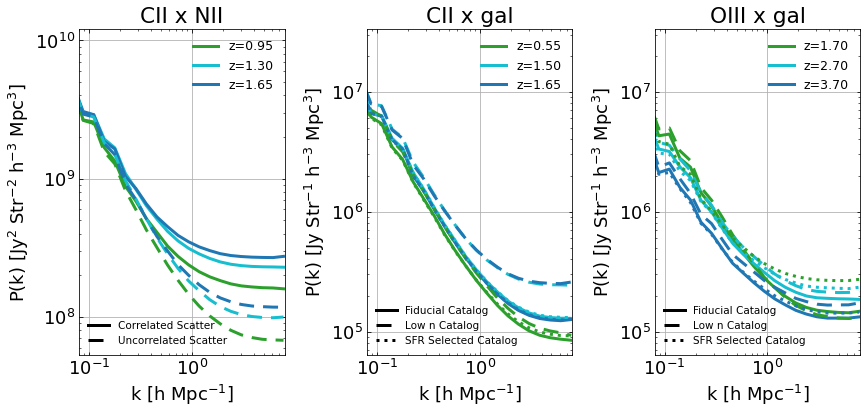

In [27]:
fig,axes = plt.subplots(1,3,figsize=(14,6),sharex=True,sharey=False)
fig.subplots_adjust(wspace=.4)
for ax in axes:
    ax.set(xlabel='k [h Mpc$^{-1}$]',xscale='log',yscale='log',xlim=xlim)
    ax.grid()
axes[0].set(title='CII x NII',ylabel=r'P(k) [Jy$^2$ Str$^{-2}$ h$^{-3}$ Mpc$^3$]')
axes[1].set(title='CII x gal',ylabel=r'P(k) [Jy Str$^{-1}$ h$^{-3}$ Mpc$^3$]')
axes[2].set(title='OIII x gal',ylabel=r'P(k) [Jy Str$^{-1}$ h$^{-3}$ Mpc$^3$]')
axes[2].sharey(axes[1])

obs_wl_colors = ['C2','C9','C0']

plot_axes = [axes[0],
             axes[1],
             axes[2],]
z_groups = [[0.95,1.3,1.65],
            [0.55,1.5,1.65],
            [1.7,2.7,3.7]]
spectra_groups = [cii_x_nii,
                  cii_x_gal,
                  oiii_x_gal,]
lines = ['-',
         '-',
         '-',]

for ax, zs, spectra, ls in zip(plot_axes,z_groups,spectra_groups,lines):
    for z, color in zip(zs,obs_wl_colors):
        snap_id = simhandler.z_to_snap(z)
        if ls == '-':
            label = "z={:.2f}".format(z)
        else:
            label = None
        ax.plot(spectra[snap_id][0],spectra[snap_id][1],color=color,label=label,linewidth=3,ls=ls)

for ax in axes:
    ax.legend(fontsize='x-small',loc='upper right')

plt.show()

fig,axes = plt.subplots(1,3,figsize=(14,6),sharex=True,sharey=False)
fig.subplots_adjust(wspace=.4)
for ax in axes:
    ax.set(xlabel='k [h Mpc$^{-1}$]',xscale='log',yscale='log',xlim=xlim)
    ax.grid()
axes[0].set(title='CII x NII',ylabel=r'P(k) [Jy$^2$ Str$^{-2}$ h$^{-3}$ Mpc$^3$]')
axes[1].set(title='CII x gal',ylabel=r'P(k) [Jy Str$^{-1}$ h$^{-3}$ Mpc$^3$]')
axes[2].set(title='OIII x gal',ylabel=r'P(k) [Jy Str$^{-1}$ h$^{-3}$ Mpc$^3$]')
axes[2].sharey(axes[1])

obs_wl_colors = ['C2','C9','C0']

plot_axes = [axes[0],axes[0],
             axes[1],axes[1],axes[1],
             axes[2],axes[2],axes[2]]
z_groups = [[0.95,1.3,1.65],[0.95,1.3,1.65],
            [0.55,1.5,1.65],[0.55,1.5,1.65],[0.55,1.5,1.65],
            [1.7,2.7,3.7],[1.7,2.7,3.7],[1.7,2.7,3.7]]
spectra_groups = [cii_x_nii,cii_x_nii_v2,
                  cii_x_gal,cii_x_gal_lown,cii_x_gal_sfr,
                  oiii_x_gal,oiii_x_gal_lown,oiii_x_gal_sfr]
lines = ['-','--',
         '-','--',':',
         '-','--',':']

for ax, zs, spectra, ls in zip(plot_axes,z_groups,spectra_groups,lines):
    for z, color in zip(zs,obs_wl_colors):
        snap_id = simhandler.z_to_snap(z)
        if ls == '-':
            label = "z={:.2f}".format(z)
        else:
            label = None
        ax.plot(spectra[snap_id][0],spectra[snap_id][1],color=color,label=label,linewidth=3,ls=ls)

l1 = axes[0].legend(fontsize='x-small',loc='upper right')
h_high_corr, = axes[0].plot([],[],'k-',lw=3,label='Correlated Scatter')
h_low_corr, = axes[0].plot([],[],'k--',lw=3,label='Uncorrelated Scatter')
h_fid, = axes[0].plot([],[],'k-',lw=3,label='Fiducial Catalog')
h_lown, = axes[0].plot([],[],'k--',lw=3,label='Low n Catalog')
h_sfr, = axes[0].plot([],[],'k:',lw=3,label='SFR Selected Catalog')
axes[0].legend(fontsize='xx-small',handles=[h_high_corr,h_low_corr],loc='lower left')
axes[0].add_artist(l1)

l2 = axes[1].legend(fontsize='xx-small',handles=[h_fid,h_lown,h_sfr],loc='lower left')
axes[1].legend(fontsize='x-small',loc='upper right')
axes[1].add_artist(l2)

l2 = axes[2].legend(fontsize='xx-small',handles=[h_fid,h_lown,h_sfr],loc='lower left')
axes[2].legend(fontsize='x-small',loc='upper right')
axes[2].add_artist(l2)

# for ax in axes:
#     ax.legend(fontsize='x-small',loc='upper right')

plt.show()

The left panel of the above figure shows the forecasted CII x NII spectrum at the 
range of redshifts where both lines are seen by TIM. The perfectly correlated
scatter and completely uncorrelated scatter cases produce shot powers that differ by 
about a factor of 2-3, but comparable clustering. This is expected as the clustering 
term is proportional to $\langle I_{CII}\rangle\langle I_{NII}\rangle$,
while the shot term is proportional to $\langle I_{CII} I_{NII}\rangle$, where the 
averages are taken over the galaxy sample, thus more correlated CII and NII emission should
increase the cross-shot noise. The true correlation in the scatter of the two lines will fall
somewhere between the extremes denoted by the dotted and dashed lines.

The middle panel shows the CII x galaxy spectrum for each of the catalogs described above.
We see that changing the selection between halo mass and SFR has little effect on 
the expected signal. Our SFRs are assigned using a scaling from halo mass, and so
the two selection methods are similar at some level. A more random selection of halos 
might induce larger changes in the signal. On the other hand, reducing the number density
of our catalog increases the shot power by about a factor of 2 for the two higher redshift 
bins, while having no effect on the lowest redshift bin. The nature of our selection 
function is such that reducing $n_gal$ increases the average halo mass. Our model assigns
SFRs (and therefore CII luminosities) which increase as a function of halo mass, up to 
a certain mass at which the halo mass-SFR correlation becomes relatively flat. In the higher 
redshift bins, selecting more massive galaxies amounts to selecting galaxies with higher 
SFR and higher CII luminosity. The CII x galaxy shot power is proportional to the average
luminosity of the galaxies used for cross correlation, therefore this increases the shot 
power. In the lowest redshift bin, the turnover in the halo mass-SFR correlation is lower,
and so there is little correlation between halo mass and CII luminosity, therefore at the
number densities considered. 

For OIII, changing the number densities has little effect, for much the same reason that
it doesn't matter in the lowest redshift CII x galaxy spectrum. On the other hand, owing
to the low number density of galaxies selected, changing our selection method from high
halo mass to high SFR has the effect of picking out objects that have scattered very high
above the mean halo mass-SFR correlation, and since our model has a tighter correlation
between OIII luminosity and SFR than between OIII luminosity and halo mass, this increases
the average OIII luminosity of the galaxy catalog and thus the OII-galaxy cross-shot noise.

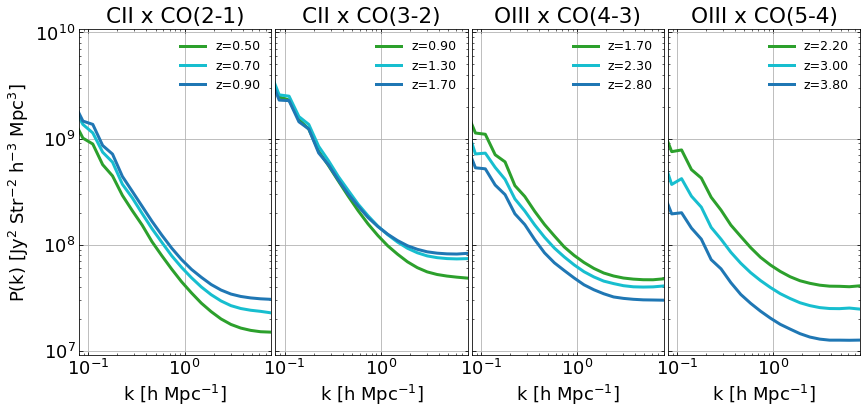

In [25]:
fig,axes = plt.subplots(1,4,figsize=(14,6),sharex=True,sharey=True)
fig.subplots_adjust(wspace=.02)
for ax in axes:
    ax.set(xlabel='k [h Mpc$^{-1}$]',xscale='log',yscale='log',xlim=xlim)
    ax.grid()
axes[0].set(ylabel=r'P(k) [Jy$^2$ Str$^{-2}$ h$^{-3}$ Mpc$^3$]')

titles = ['CII x CO(2-1)','CII x CO(3-2)','OIII x CO(4-3)','OIII x CO(5-4)']
zs = [0.5,0.7,0.9]
z_groups = [[0.5,0.7,0.9],
            [0.9,1.3,1.7],
            [1.7,2.3,2.8],
            [2.2,3.0,3.8]]
spectra_groups = [cii_x_co2,cii_x_co3,oiii_x_co4,oiii_x_co5]

for ax, zs, spectra, title in zip(axes,z_groups,spectra_groups,titles):
    for z, color in zip(zs,obs_wl_colors):
        snap_id = simhandler.z_to_snap(z)
        ax.set(title=title)
        ax.plot(spectra[snap_id][0],spectra[snap_id][1],color=color,label="z={:.2f}".format(z),linewidth=3)

for ax in axes:
    ax.legend(fontsize='x-small',loc='upper right')

plt.show()